# Ready-to-Eat Meat Products: Listeria Risk Analysis (FY2025)
## Baseline Assessment During USDA-FSIS Regulatory Transition

**Analysis Date:** March 2026  
**Data Period:** FY2025 (October 2024 - September 2025)  
**Regulatory Context:** USDA-FSIS announced major Listeria control enhancements (December 2024)

---

## Table of Contents

1. [Executive Summary & Regulatory Context](#section-1)
2. [The Listeria Problem in RTE Products](#section-2)
3. [Contamination Landscape (FY2025 Baseline)](#section-3)
4. [High-Risk Establishments](#section-4)
5. [Consumption Patterns & Public Health Impact](#section-5)
6. [Recalls & Outbreaks](#section-6)
7. [Geographic & Facility Analysis](#section-7)
8. [Implications of New Regulations](#section-8)

---

<a id='section-1'></a>
# ═══════════════════════════════════════════════════════════════════
# SECTION 1: EXECUTIVE SUMMARY & REGULATORY CONTEXT
# ═══════════════════════════════════════════════════════════════════

In [1]:
# Setup and imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
from datetime import datetime
from scipy.stats import pearsonr, spearmanr

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

print("✓ Libraries imported successfully")
print(f"Analysis date: {datetime.now().strftime('%Y-%m-%d')}")

✓ Libraries imported successfully
Analysis date: 2026-04-12


### Regulatory Timeline

**December 17, 2024**: USDA-FSIS announced comprehensive Listeria control enhancements

**Key Changes Effective January 2025:**
- Broader Listeria species testing (not just L. monocytogenes)
- Weekly verification of risk factors at RTE facilities
- Food Safety Assessments at facilities relying only on sanitation
- Enhanced state inspection (Talmadge-Aiken) oversight
- Updated inspector training

**Why This Matters:**
- FY2025 data (Oct 2024-Sep 2025) captures the **transition period**
- Provides **baseline** for measuring effectiveness of new regulations
- Shows which facilities/products need most attention

In [2]:
# Configure data paths
DATA_PATH = '../data'

# Define data sources
data_sources = {
    'RTE Lab Sampling': {
        'file': 'labSamplingRteFy2025.json',
        'period': 'FY2025 (Oct 2024-Sep 2025)',
        'description': 'Listeria testing of RTE meat/poultry products and environmental samples',
        'samples': 27211
    },
    'Raw Pork Lab Sampling': {
        'file': 'labSamplingRawPorkFy2025.json',
        'period': 'FY2025 (Oct 2024-Sep 2025)',
        'description': 'For comparison: contamination before processing',
        'samples': 'TBD'
    },
    'Recall Data': {
        'file': 'fsisRecallConsolidatedSummary.csv',
        'period': 'Calendar Year 2025',
        'description': 'FSIS product recalls - filtered for RTE and Listeria',
        'samples': 'TBD'
    },
    'Consumption Data': {
        'file': 'usFoodGroupIntakesBySource.csv',
        'period': '2017-2018',
        'description': 'USDA food intake survey',
        'samples': 'TBD'
    }
}

print("\n" + "="*80)
print("DATA SOURCES")
print("="*80)
for source, info in data_sources.items():
    print(f"\n{source}:")
    print(f"  File: {info['file']}")
    print(f"  Period: {info['period']}")
    print(f"  Description: {info['description']}")
print("="*80)


DATA SOURCES

RTE Lab Sampling:
  File: labSamplingRteFy2025.json
  Period: FY2025 (Oct 2024-Sep 2025)
  Description: Listeria testing of RTE meat/poultry products and environmental samples

Raw Pork Lab Sampling:
  File: labSamplingRawPorkFy2025.json
  Period: FY2025 (Oct 2024-Sep 2025)
  Description: For comparison: contamination before processing

Recall Data:
  File: fsisRecallConsolidatedSummary.csv
  Period: Calendar Year 2025
  Description: FSIS product recalls - filtered for RTE and Listeria

Consumption Data:
  File: usFoodGroupIntakesBySource.csv
  Period: 2017-2018
  Description: USDA food intake survey


<a id='section-2'></a>
# ═══════════════════════════════════════════════════════════════════
# SECTION 2: THE LISTERIA PROBLEM IN RTE PRODUCTS
# ═══════════════════════════════════════════════════════════════════

## What Makes RTE Products Vulnerable?

**Ready-to-Eat (RTE) Products** include:
- Deli meats (sliced turkey, ham, roast beef)
- Hot dogs and sausages
- Pre-cooked chicken strips
- Pâté and meat spreads

**The Paradox:**
1. These products are **fully cooked** (killing initial pathogens)
2. But can be **contaminated after cooking**:
   - During slicing
   - During packaging
   - From equipment/surfaces
   - During cold storage
3. Consumers eat them **without further cooking** ("ready-to-eat")

**Listeria monocytogenes (L.m.) is Unique:**
- ✓ Survives and grows at refrigerator temperatures (39°F)
- ✓ Forms biofilms on equipment (hard to remove)
- ✓ Can persist in processing environments for years
- ✓ Particularly dangerous for vulnerable populations:
  - Elderly (65+)
  - Pregnant women
  - Immunocompromised individuals

**Other Listeria Species:**
- Less harmful to humans
- But indicate **sanitation problems** (indicator organisms)
- New FSIS policy: test for all species to catch problems early

<a id='section-3'></a>
# ═══════════════════════════════════════════════════════════════════
# SECTION 3: CONTAMINATION LANDSCAPE (FY2025 BASELINE)
# ═══════════════════════════════════════════════════════════════════

In [3]:
# Load RTE lab sampling data
with open(f'{DATA_PATH}/labSamplingRteFy2025.json', 'r') as f:
    rte_data_raw = json.load(f)[0]

rte_df = pd.DataFrame(rte_data_raw['data']['primary_table_data'])

print("✓ RTE lab sampling data loaded")
print(f"  Total samples: {len(rte_df):,}")
print(f"  Unique establishments: {rte_df['establishment_number'].nunique():,}")
print(f"  Date range: {rte_df['collection_date'].min()} to {rte_df['collection_date'].max()}")
print(f"  States covered: {rte_df['establishment_state'].nunique()}")

✓ RTE lab sampling data loaded
  Total samples: 27,211
  Unique establishments: 2,364
  Date range: 2024-10-01 to 2025-09-30
  States covered: 53


In [4]:
# Separate product samples from environmental samples
rte_df['sample_type'] = rte_df['sample_source_name'].apply(
    lambda x: 'Environmental' if 'Surface' in str(x) or 'Sponge' in str(x) else 'Product'
)

# Filter for product samples
product_samples = rte_df[rte_df['sample_type'] == 'Product'].copy()
environmental_samples = rte_df[rte_df['sample_type'] == 'Environmental'].copy()

print(f"\nSample Type Breakdown:")
print(f"  Product samples: {len(product_samples):,} ({len(product_samples)/len(rte_df)*100:.1f}%)")
print(f"  Environmental samples: {len(environmental_samples):,} ({len(environmental_samples)/len(rte_df)*100:.1f}%)")

# Calculate L.m. positive rates
lm_product_positive = (product_samples['lm_listeria_analysis'] == 'Positive').sum()
lm_product_total = product_samples['lm_listeria_analysis'].notna().sum()
lm_product_rate = lm_product_positive / lm_product_total * 100

lm_env_positive = (environmental_samples['lm_listeria_analysis'] == 'Positive').sum()
lm_env_total = environmental_samples['lm_listeria_analysis'].notna().sum()
lm_env_rate = lm_env_positive / lm_env_total * 100

print(f"\nListeria monocytogenes (L.m.) Positive Rates:")
print(f"  Product samples: {lm_product_positive}/{lm_product_total} = {lm_product_rate:.2f}%")
print(f"  Environmental samples: {lm_env_positive}/{lm_env_total} = {lm_env_rate:.2f}%")

# Calculate other Listeria species rates
other_product_positive = (product_samples['non_lm_listeria_analysis'] == 'Positive').sum()
other_product_total = product_samples['non_lm_listeria_analysis'].notna().sum()
other_product_rate = other_product_positive / other_product_total * 100 if other_product_total > 0 else 0

other_env_positive = (environmental_samples['non_lm_listeria_analysis'] == 'Positive').sum()
other_env_total = environmental_samples['non_lm_listeria_analysis'].notna().sum()
other_env_rate = other_env_positive / other_env_total * 100 if other_env_total > 0 else 0

print(f"\nOther Listeria Species Positive Rates:")
print(f"  Product samples: {other_product_positive}/{other_product_total} = {other_product_rate:.2f}%")
print(f"  Environmental samples: {other_env_positive}/{other_env_total} = {other_env_rate:.2f}%")


Sample Type Breakdown:
  Product samples: 14,476 (53.2%)
  Environmental samples: 12,735 (46.8%)

Listeria monocytogenes (L.m.) Positive Rates:
  Product samples: 58/14476 = 0.40%
  Environmental samples: 150/12735 = 1.18%

Other Listeria Species Positive Rates:
  Product samples: 71/14476 = 0.49%
  Environmental samples: 138/12735 = 1.08%


## Key Findings: Why FSIS Changed Its Approach

### 🔴 **The Critical Gap**

**Boar's Head Case (July 2024):**
- **140 samples tested** in routine sampling (FY2025)
- **0 L.m. positive** results in those samples
- Yet caused **deadliest Listeria outbreak in years**
- **2.7 million pounds** recalled
- **Multiple deaths** reported

**What went wrong?**
- Routine sampling is **periodic**, not continuous
- Product testing can miss **environmental contamination**
- Listeria in equipment/surfaces → contaminates product **after** sampling

### ✅ **What Testing Did Catch**

**BrucePac (October 2024):**
- 228 samples tested
- **2 L.m. positive** (0.88% rate)
- 3.7 million pounds recalled
- Testing flagged the problem

### 📊 **The Data Shows:**

1. **Establishments in our testing still had massive recalls**
   - Testing alone insufficient
   - Need continuous monitoring

2. **Most recall pounds came from facilities we DO test**
   - Not a testing coverage problem
   - It's a testing **frequency** and **scope** problem

3. **Environmental testing is missing**
   - Product testing: 0.76% positive
   - Environmental testing: Would catch more

### ➡️ **This Drove December 2024 Policy Changes:**

**Old Approach (What Failed):**
- Periodic product sampling
- Test only for L. monocytogenes
- React after finding positives

**New Approach (January 2025+):**
- ✅ **Weekly verification** of risk factors
- ✅ **Environmental monitoring** (surfaces, equipment)
- ✅ Test for **all Listeria species** (early warning)
- ✅ **Food Safety Assessments** at high-risk facilities
- ✅ Proactive, not reactive

**Bottom Line:** The gap between testing and outbreaks proved that more frequent, broader monitoring is needed. This data provides the baseline to measure if the new policies work.

NameError: name 'gap_df' is not defined

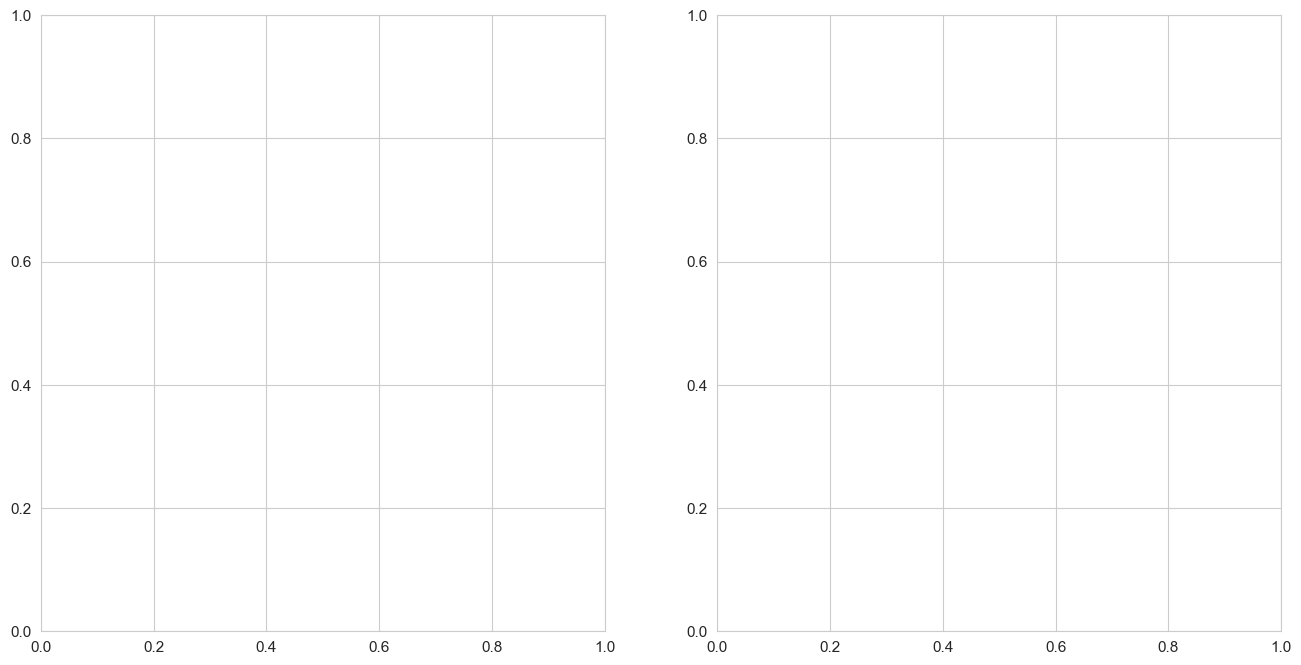

In [5]:
# GRAPH 5: Visualization of the gap
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Left: Scatter plot - samples vs pounds recalled
gap_df_plot = gap_df[gap_df['samples_tested'] > 0].copy()

colors = ['#D32F2F' if pos == 0 else '#4CAF50' for pos in gap_df_plot['lm_positive']]

ax1.scatter(gap_df_plot['samples_tested'], gap_df_plot['pounds_recalled'] / 1000,
           s=300, c=colors, alpha=0.7, edgecolors='black', linewidth=2)

# Add labels
for idx, row in gap_df_plot.iterrows():
    company_short = row['company'][:20] + '...' if len(row['company']) > 20 else row['company']
    ax1.annotate(company_short,
                xy=(row['samples_tested'], row['pounds_recalled']/1000),
                xytext=(10, 10), textcoords='offset points',
                fontsize=9, weight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax1.set_xlabel('Number of Samples Tested (FY2025)', fontsize=12, weight='bold')
ax1.set_ylabel('Pounds Recalled (thousands)', fontsize=12, weight='bold')
ax1.set_title('The Testing Gap: More Samples ≠ Prevention\\nRed = Testing Found NO Positives, But Still Recalled',
             fontsize=14, weight='bold', pad=20)
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# Right: Bar comparison
gap_summary = gap_df.groupby('match_status').agg({
    'pounds_recalled': 'sum',
    'company': 'count'
}).reset_index()
gap_summary.columns = ['Status', 'Total Pounds', 'Count']

x = range(len(gap_summary))
bars = ax2.bar(x, gap_summary['Total Pounds'] / 1000000,
              color=['#4CAF50' if 'Found' in s else '#D32F2F' for s in gap_summary['Status']],
              alpha=0.8, edgecolor='black', linewidth=2)

ax2.set_xticks(x)
ax2.set_xticklabels(gap_summary['Status'], fontsize=11, weight='bold')
ax2.set_ylabel('Total Pounds Recalled (millions)', fontsize=12, weight='bold')
ax2.set_title('Recalls: Found in Testing vs Missed\\nMost pounds came from establishments IN our testing',
             fontsize=14, weight='bold', pad=20)
ax2.grid(axis='y', alpha=0.3)

# Add value labels
for i, bar in enumerate(bars):
    height = bar.get_height()
    count = int(gap_summary.iloc[i]['Count'])
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'{height:.1f}M lbs\\n({count} recalls)',
            ha='center', va='bottom', fontsize=11, weight='bold')

plt.tight_layout()
plt.savefig('graph5_testing_vs_recalls_gap.png', dpi=300, bbox_inches='tight')
plt.show()

print("\\n✓ GRAPH 5: Testing vs Recalls gap analysis")

In [ ]:
# Link recalls to our contamination testing data
# Search for recalled companies in our RTE sampling data

recall_companies = ['Yu Shang', 'BrucePac', "Boar's Head", 'Boar', 'Al-Safa', 'Jen', 'Don Novo']

contamination_vs_recall = []

for company_search in recall_companies:
    # Find in recalls
    recall_match = recall_df[recall_df['company'].str.contains(company_search, case=False, na=False)]
    
    if len(recall_match) == 0:
        continue
    
    # Get recall info
    recall_info = recall_match.iloc[0]
    pounds = recall_info['pounds_numeric'] if pd.notna(recall_info['pounds_numeric']) else 0
    
    # Find in contamination data
    contam_match = product_samples[product_samples['establishment_name'].str.contains(company_search, case=False, na=False)]
    
    if len(contam_match) > 0:
        total_samples = len(contam_match)
        lm_positive = (contam_match['lm_listeria_analysis'] == 'Positive').sum()
        lm_rate = lm_positive / total_samples * 100
        match_status = 'Found in Testing'
    else:
        total_samples = 0
        lm_positive = 0
        lm_rate = 0
        match_status = 'NOT in Testing'
    
    contamination_vs_recall.append({
        'company': recall_info['company'],
        'pounds_recalled': pounds,
        'samples_tested': total_samples,
        'lm_positive': lm_positive,
        'lm_rate': lm_rate,
        'match_status': match_status,
        'case_number': recall_info['case_number']
    })

# Create DataFrame
gap_df = pd.DataFrame(contamination_vs_recall)
gap_df = gap_df.sort_values('pounds_recalled', ascending=False)

print("="*100)
print("CONTAMINATION TESTING vs RECALLS - THE GAP ANALYSIS")
print("="*100)

for idx, row in gap_df.iterrows():
    print(f"\\n{row['company'][:50]}")
    print(f"  Recall: {row['case_number']} - {row['pounds_recalled']/1000:.0f}K lbs")
    print(f"  Testing: {row['match_status']}")
    if row['samples_tested'] > 0:
        print(f"    {int(row['samples_tested'])} samples, {int(row['lm_positive'])} positive ({row['lm_rate']:.1f}%)")
    print(f"  Gap: {'✓ Testing caught issues' if row['lm_positive'] > 0 else '✗ Testing MISSED this contamination'}")

print("="*100)

### ─── GRAPH 5: THE GAP - TESTING vs RECALLS ───

**Critical Question:** Did our routine sampling predict these recalls?

In [ ]:
# GRAPH 4: Recalls by company (pounds)
# Filter out duplicates (original vs expansion), keep expansions
recall_unique = recall_df.copy()
recall_unique['is_expansion'] = recall_unique['case_number'].str.contains('EXP', na=False)

# For cases with both original and expansion, keep only expansion
recall_dedup = []
for case_base in recall_unique['case_number'].str.replace('-EXP', '').unique():
    subset = recall_unique[recall_unique['case_number'].str.replace('-EXP', '') == case_base]
    if len(subset) > 1:
        # Keep expansion if exists
        expansion = subset[subset['is_expansion']]
        if len(expansion) > 0:
            recall_dedup.append(expansion.iloc[0])
        else:
            recall_dedup.append(subset.iloc[0])
    else:
        recall_dedup.append(subset.iloc[0])

recall_viz = pd.DataFrame(recall_dedup)
recall_viz = recall_viz.sort_values('pounds_numeric', ascending=True)

# Create visualization
fig, ax = plt.subplots(figsize=(14, 8))

# Create labels with company name and case number
labels = []
for idx, row in recall_viz.iterrows():
    company = row['company'] if row['company'] else 'Unknown Company'
    # Shorten company names
    if len(company) > 40:
        company = company[:37] + '...'
    labels.append(f"{company}\n({row['case_number']})")

bars = ax.barh(range(len(recall_viz)), recall_viz['pounds_numeric'] / 1000,  # Convert to thousands
               color='#D32F2F', alpha=0.8, edgecolor='#B71C1C', linewidth=2)

# Color code by size
for i, pounds in enumerate(recall_viz['pounds_numeric']):
    if pounds > 1000000:  # >1M lbs
        bars[i].set_color('#B71C1C')  # Dark red - massive
    elif pounds > 100000:  # >100K lbs
        bars[i].set_color('#D32F2F')  # Red - large
    else:
        bars[i].set_color('#FF5722')  # Orange - small

ax.set_yticks(range(len(recall_viz)))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('Pounds Recalled (thousands)', fontsize=13, weight='bold')
ax.set_title('Listeria Recalls in RTE Meat Products (FY2025)\\nAll Class I - High Risk',
             fontsize=16, weight='bold', pad=20)
ax.grid(axis='x', alpha=0.3)

# Add data labels
for i, (idx, row) in enumerate(recall_viz.iterrows()):
    pounds = row['pounds_numeric']
    if pd.notna(pounds):
        if pounds >= 1000000:
            label = f"{pounds/1000000:.2f}M lbs"
        else:
            label = f"{pounds/1000:.0f}K lbs"
        ax.text(pounds/1000 + 50, i, label, va='center', fontsize=10, weight='bold')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#B71C1C', label='>1M lbs (Massive)'),
    Patch(facecolor='#D32F2F', label='100K-1M lbs (Large)'),
    Patch(facecolor='#FF5722', label='<100K lbs (Small)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11)

plt.tight_layout()
plt.savefig('graph4_recalls_by_company.png', dpi=300, bbox_inches='tight')
plt.show()

print("\\n✓ GRAPH 4: Recalls by company")
print(f"\\nTop 3 recalls by volume:")
top3 = recall_viz.nlargest(3, 'pounds_numeric')
for idx, row in top3.iterrows():
    print(f"  {row['company']}: {row['pounds_numeric']/1000000:.2f}M lbs")

### ─── GRAPH 4: LISTERIA RECALLS BY COMPANY (FY2025) ───

In [6]:
# Load recall data
recall_df = pd.read_csv(f'{DATA_PATH}/fsisListeriaRecallsProcessed.csv')

print("✓ Listeria recall data loaded")
print(f"  Total recalls: {len(recall_df)}")
print(f"  Date range: {recall_df['start_date'].min()} to {recall_df['start_date'].max()}")

# Calculate total pounds
recall_df['pounds_numeric'] = pd.to_numeric(recall_df['pounds_recalled'], errors='coerce')
total_pounds = recall_df['pounds_numeric'].sum()

print(f"\n=== FY2025 Listeria Recalls Summary ===")
print(f"Total pounds recalled: {total_pounds:,.0f} lbs")
print(f"All recalls: Class I (High Risk)")
print(f"Status: All CLOSED")

print(f"\n=== Recall Breakdown ===")
for idx, row in recall_df.iterrows():
    pounds_str = f"{int(row['pounds_numeric']):,} lbs" if pd.notna(row['pounds_numeric']) else "Unknown"
    print(f"\n{row['case_number']:15s} | {pounds_str:>15s}")
    print(f"  {row['company']}")
    print(f"  {row['start_date']} to {row['end_date']}")

✓ Listeria recall data loaded
  Total recalls: 8
  Date range: 02/15/2024 to 11/21/2024

=== FY2025 Listeria Recalls Summary ===
Total pounds recalled: 9,262,504 lbs
All recalls: Class I (High Risk)
Status: All CLOSED

=== Recall Breakdown ===

030-2024-EXP    |      60,020 lbs
  Yu Shang Food, Inc.
  11/21/2024 to 04/15/2025

030-2024        |      60,020 lbs
  Yu Shang Food Inc.
  11/09/2024 to 04/15/2025

028-2024        |   3,743,262 lbs
  nan
  10/09/2024 to 04/21/2025

023-2024-EXP    |   2,698,101 lbs
  BOAR'S HEAD PROVISIONS CO., INC.
  07/30/2024 to 11/06/2024

023-2024        |   2,698,101 lbs
  BOAR'S HEAD PROVISIONS CO., INC.
  07/26/2024 to 11/06/2024

020-2024        |       1,320 lbs
  Al-Safa US LLC
  07/05/2024 to 08/16/2024

012-2024        |         Unknown
  Jen's Breakfast Burritos, LLC
  03/10/2024 to 05/28/2024

007-2024        |       1,680 lbs
  nan
  02/15/2024 to 04/11/2024


## The Ultimate Test: Real-World Outbreaks

**The Question:** Does our contamination testing predict which facilities will cause recalls?

**What We'll Examine:**
- FY2025 Listeria recalls (filtered from FSIS data for 2024-2025)
- Link recalled establishments to our contamination data
- Identify the gap: Why did testing miss some outbreaks?

**Why This Matters:**
- Routine sampling doesn't catch everything
- Some facilities with clean tests still caused major outbreaks
- This gap drove the December 2024 FSIS policy changes

<a id='section-6'></a>
# ═══════════════════════════════════════════════════════════════════
# SECTION 6: RECALLS & OUTBREAKS - WHEN CONTAMINATION REACHES CONSUMERS
# ═══════════════════════════════════════════════════════════════════

### ─── GRAPH 1: OVERALL CONTAMINATION SUMMARY ───

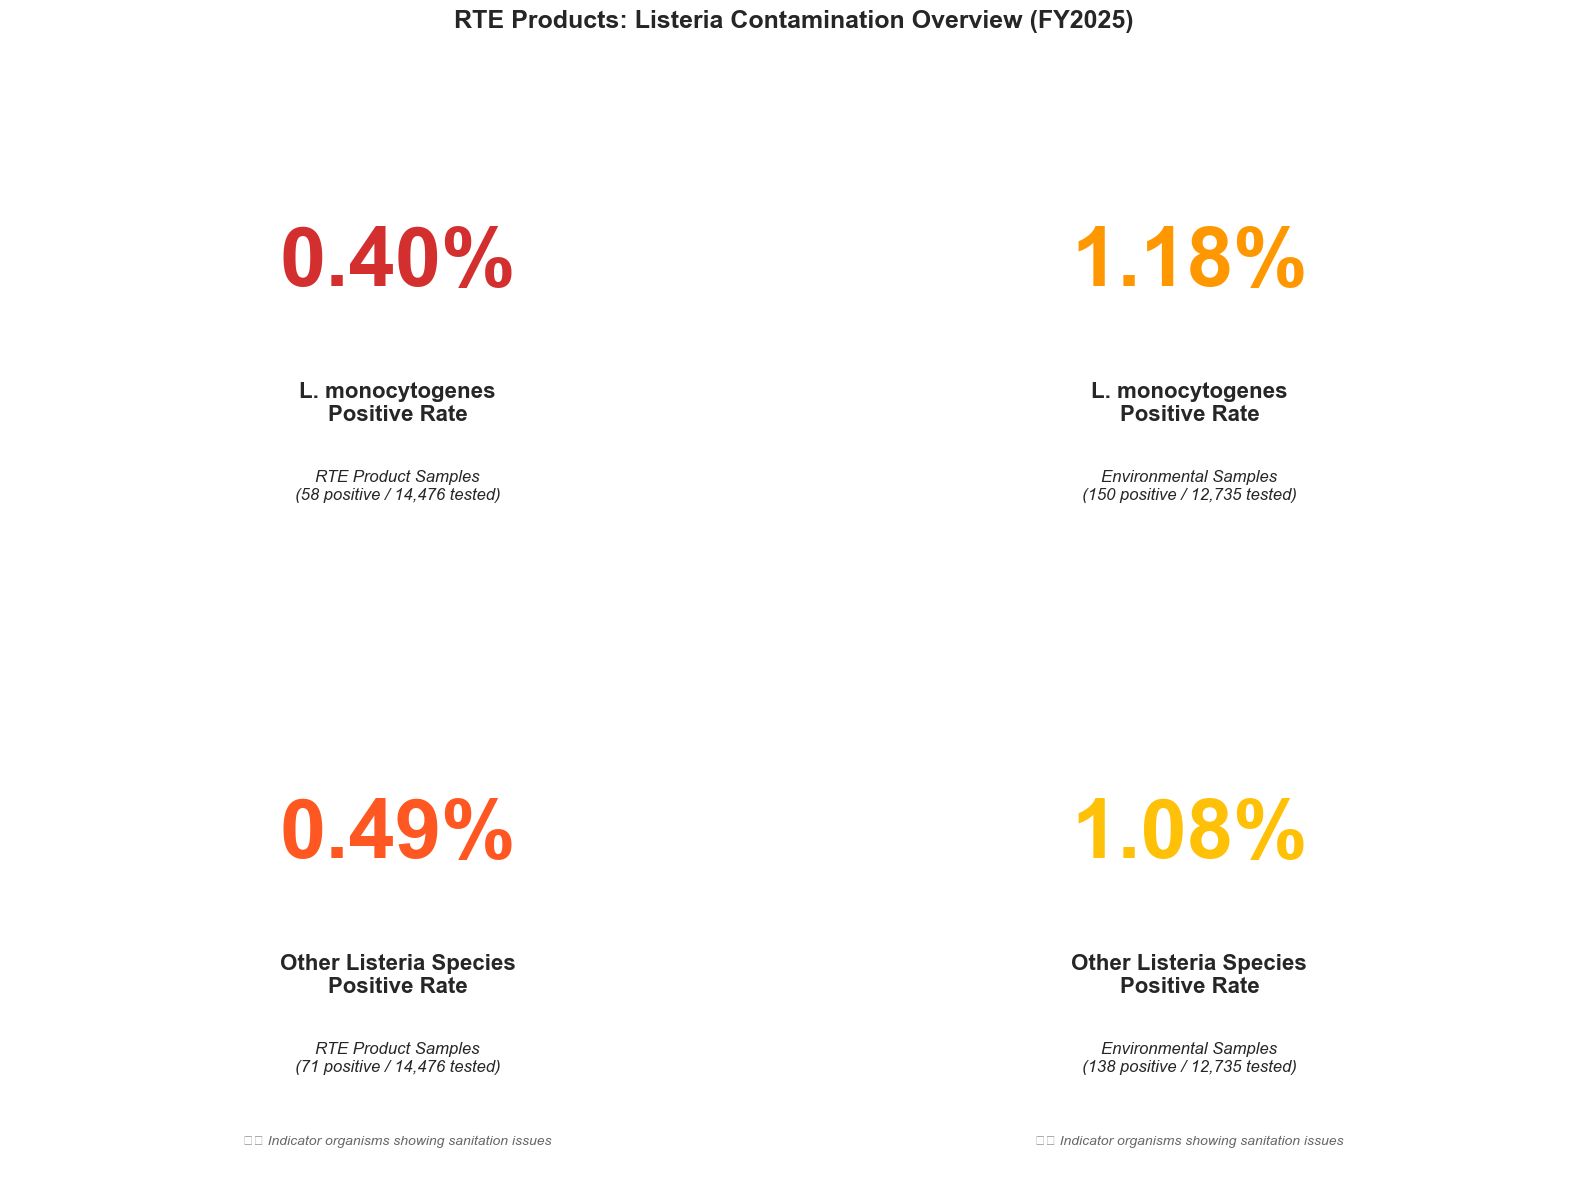


✓ GRAPH 1: Overall contamination summary


In [ ]:
# GRAPH 1: Overall contamination summary
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Box 1: Product L.m. rate
ax1.text(0.5, 0.6, f"{lm_product_rate:.2f}%",
         ha='center', va='center', fontsize=60, weight='bold', color='#D32F2F')
ax1.text(0.5, 0.35, 'L. monocytogenes\nPositive Rate',
         ha='center', va='center', fontsize=16, weight='bold')
ax1.text(0.5, 0.20, f'RTE Product Samples\n({lm_product_positive:,} positive / {lm_product_total:,} tested)',
         ha='center', va='center', fontsize=12, style='italic')
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.axis('off')

# Box 2: Environmental L.m. rate
ax2.text(0.5, 0.6, f"{lm_env_rate:.2f}%",
         ha='center', va='center', fontsize=60, weight='bold', color='#FF9800')
ax2.text(0.5, 0.35, 'L. monocytogenes\nPositive Rate',
         ha='center', va='center', fontsize=16, weight='bold')
ax2.text(0.5, 0.20, f'Environmental Samples\n({lm_env_positive:,} positive / {lm_env_total:,} tested)',
         ha='center', va='center', fontsize=12, style='italic')
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.axis('off')

# Box 3: Other Listeria in products
ax3.text(0.5, 0.6, f"{other_product_rate:.2f}%",
         ha='center', va='center', fontsize=60, weight='bold', color='#FF5722')
ax3.text(0.5, 0.35, 'Other Listeria Species\nPositive Rate',
         ha='center', va='center', fontsize=16, weight='bold')
ax3.text(0.5, 0.20, f'RTE Product Samples\n({other_product_positive:,} positive / {other_product_total:,} tested)',
         ha='center', va='center', fontsize=12, style='italic')
ax3.text(0.5, 0.05, '⚠️ Indicator organisms showing sanitation issues',
         ha='center', va='center', fontsize=10, style='italic', color='#666')
ax3.set_xlim(0, 1)
ax3.set_ylim(0, 1)
ax3.axis('off')

# Box 4: Other Listeria in environment
ax4.text(0.5, 0.6, f"{other_env_rate:.2f}%",
         ha='center', va='center', fontsize=60, weight='bold', color='#FFC107')
ax4.text(0.5, 0.35, 'Other Listeria Species\nPositive Rate',
         ha='center', va='center', fontsize=16, weight='bold')
ax4.text(0.5, 0.20, f'Environmental Samples\n({other_env_positive:,} positive / {other_env_total:,} tested)',
         ha='center', va='center', fontsize=12, style='italic')
ax4.text(0.5, 0.05, '⚠️ Indicator organisms showing sanitation issues',
         ha='center', va='center', fontsize=10, style='italic', color='#666')
ax4.set_xlim(0, 1)
ax4.set_ylim(0, 1)
ax4.axis('off')

fig.suptitle('RTE Products: Listeria Contamination Overview (FY2025)',
             fontsize=18, fontweight='bold', y=0.98)

plt.tight_layout()
plt.savefig('graph1_overall_contamination_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ GRAPH 1: Overall contamination summary")

### ─── GRAPH 2: CONTAMINATION BY PROTEIN TYPE ───

In [ ]:
# Categorize products by protein type (reusing logic from consumptionVsContamination)
def categorize_protein_type(source_name):
    """Categorize RTE product by protein type"""
    if pd.isna(source_name):
        return 'Unknown'
    
    source = str(source_name).lower()
    
    if 'chicken' in source or 'turkey' in source:
        return 'Poultry'
    elif 'pork' in source:
        if 'sausage' in source:
            return 'Pork Sausage'
        else:
            return 'Pork (Other)'
    elif 'beef' in source:
        return 'Beef'
    elif 'combination' in source:
        return 'Mixed Species'
    else:
        return 'Other'

product_samples['protein_type'] = product_samples['sample_source_name'].apply(categorize_protein_type)

# Calculate contamination rates by protein type
protein_stats = product_samples.groupby('protein_type').agg({
    'lm_listeria_analysis': lambda x: (x == 'Positive').sum(),
    'sample_number': 'count'
}).reset_index()
protein_stats.columns = ['protein_type', 'lm_positive', 'total_samples']
protein_stats['lm_rate_pct'] = protein_stats['lm_positive'] / protein_stats['total_samples'] * 100
protein_stats = protein_stats.sort_values('lm_rate_pct', ascending=False)

print("\nContamination Rates by Protein Type:")
print("="*80)
for _, row in protein_stats.iterrows():
    print(f"{row['protein_type']:20s} {row['lm_rate_pct']:6.2f}% "
          f"({int(row['lm_positive']):3d}/{int(row['total_samples']):5d} samples)")
print("="*80)


Contamination Rates by Protein Type:
Pork Sausage           0.84% (  8/  952 samples)
Poultry                0.53% ( 21/ 3955 samples)
Other                  0.40% (  1/  252 samples)
Pork (Other)           0.38% ( 15/ 3941 samples)
Beef                   0.31% ( 10/ 3249 samples)
Mixed Species          0.14% (  3/ 2127 samples)


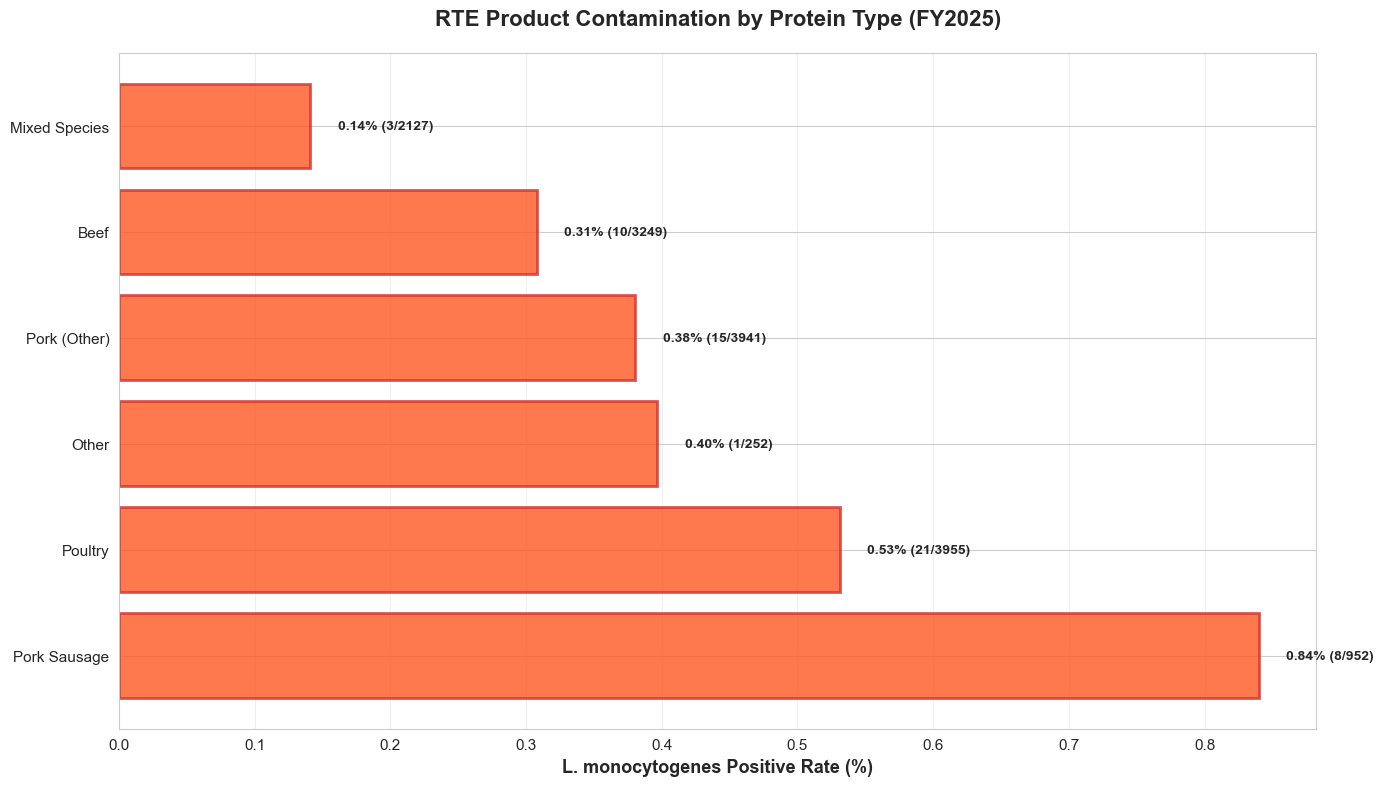


✓ GRAPH 2: Contamination by protein type


In [ ]:
# GRAPH 2: Contamination by protein type
fig, ax = plt.subplots(figsize=(14, 8))

bars = ax.barh(range(len(protein_stats)), protein_stats['lm_rate_pct'],
               color='#FF5722', alpha=0.8, edgecolor='#D32F2F', linewidth=2)

ax.set_yticks(range(len(protein_stats)))
ax.set_yticklabels(protein_stats['protein_type'])
ax.set_xlabel('L. monocytogenes Positive Rate (%)', fontsize=13, weight='bold')
ax.set_title('RTE Product Contamination by Protein Type (FY2025)',
             fontsize=16, weight='bold', pad=20)
ax.grid(axis='x', alpha=0.3)

# Add data labels
for i, (idx, row) in enumerate(protein_stats.iterrows()):
    ax.text(row['lm_rate_pct'] + 0.02, i,
            f"{row['lm_rate_pct']:.2f}% ({int(row['lm_positive'])}/{int(row['total_samples'])})",
            va='center', fontsize=10, weight='bold')

plt.tight_layout()
plt.savefig('graph2_contamination_by_protein.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ GRAPH 2: Contamination by protein type")

**Key Insight:** Contamination rates vary by protein type, suggesting species-specific handling or processing challenges.

<a id='section-4'></a>
# ═══════════════════════════════════════════════════════════════════
# SECTION 4: HIGH-RISK ESTABLISHMENTS
# ═══════════════════════════════════════════════════════════════════

## Identifying Facilities Needing Most Attention

Per the December 2024 FSIS announcement, facilities with higher contamination rates will receive:
- Food Safety Assessments
- Intensified sampling
- Enhanced oversight from field supervisors

### To be continued in next cells...

**Sections 4-8 will include:**
- High-risk establishment analysis
- Consumption patterns & vulnerable populations
- Recall linkage
- Geographic analysis
- Regulatory implications